# Product Recommendation Engine

## Overview
This notebook builds a product recommendation engine for the Olist e-commerce dataset. We will implement:
1.  **Popularity-Based Recommender:** Suggests top-selling products (baseline).
2.  **Collaborative Filtering (SVD):** Suggests personalized products based on user purchase history.

## Objectives
1.  **Data Prep:** Create a User-Item interaction matrix.
2.  **Baseline Model:** Build and evaluate a popularity-based model.
3.  **Advanced Model:** Build and evaluate an SVD-based collaborative filtering model.

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# %matplotlib inline

In [2]:
# Connect to the SQLite database
db_path = '../Project1 (DA)/olist.db'
conn = sqlite3.connect(db_path)

print(f"Connected to database at: {db_path}")

Connected to database at: ../Project1 (DA)/olist.db


## 1. Data Extraction
We need to construct a dataset of **User-Item Interactions**.
In e-commerce, a "purchase" is an implicit rating. We can treat the number of times a user bought an item as the "rating" or "strength of interaction".

We need:
-   `customer_unique_id`: The user.
-   `product_id`: The item.
-   `order_id`: To count interactions.

In [3]:
query = """
SELECT 
    c.customer_unique_id,
    oi.product_id,
    COUNT(oi.order_id) as purchase_count
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_unique_id, oi.product_id
"""

df = pd.read_sql(query, conn)

print(f"Total Interactions: {len(df):,}")
print(f"Unique Users: {df['customer_unique_id'].nunique():,}")
print(f"Unique Products: {df['product_id'].nunique():,}")
display(df.head())

Total Interactions: 101,987
Unique Users: 95,420
Unique Products: 32,951


,customer_unique_id,product_id,purchase_count
0,0000366f3b9a7992bf8c76cfdf3221e2,372645c7439f9661fbbacfd129aa92ec,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,5099f7000472b634fea8304448d20825,1
2,0000f46a3911fa3c0805444483337064,64b488de448a5324c4134ea39c28a34b,1
3,0000f6ccb0745a6a4b88665a16c9f078,2345a354a6f2033609bbf62bf5be9ef6,1
4,0004aac84e0df4da2b147fca70cf8255,c72e18b3fe2739b8d24ebf3102450f37,1


## 2. Popularity-Based Recommender (Baseline)
The simplest recommendation is to suggest the most popular items to every user. This is useful for:
-   **Cold Start:** When we know nothing about a new user.
-   **Benchmark:** To compare against more complex models.

We will rank products by total number of purchases.

In [4]:
# Calculate popularity (total purchase count per product)
popular_products = df.groupby('product_id')['purchase_count'].sum().reset_index()
popular_products = popular_products.sort_values(by='purchase_count', ascending=False)

# Get product category names for better readability
query_products = """
SELECT product_id, product_category_name
FROM products
"""
products_df = pd.read_sql(query_products, conn)

# Merge with popularity data
popular_products = popular_products.merge(products_df, on='product_id', how='left')

print("Top 10 Most Popular Products:")
display(popular_products.head(10))

Top 10 Most Popular Products:


,product_id,purchase_count,product_category_name
0,aca2eb7d00ea1a7b8ebd4e68314663af,527,moveis_decoracao
1,99a4788cb24856965c36a24e339b6058,488,cama_mesa_banho
2,422879e10f46682990de24d770e7f83d,484,ferramentas_jardim
3,389d119b48cf3043d311335e499d9c6b,392,ferramentas_jardim
4,368c6c730842d78016ad823897a372db,388,ferramentas_jardim
5,53759a2ecddad2bb87a079a1f1519f73,373,ferramentas_jardim
6,d1c427060a0f73f6b889a5c7c61f2ac4,343,informatica_acessorios
7,53b36df67ebb7c41585e8d54d6772e08,323,relogios_presentes
8,154e7e31ebfa092203795c972e5804a6,281,beleza_saude
9,3dd2a17168ec895c781a9191c1e95ad7,274,informatica_acessorios


/tmp/ipykernel_284649/3339253538.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_categories, x='purchase_count', y='product_category_name', palette='viridis')


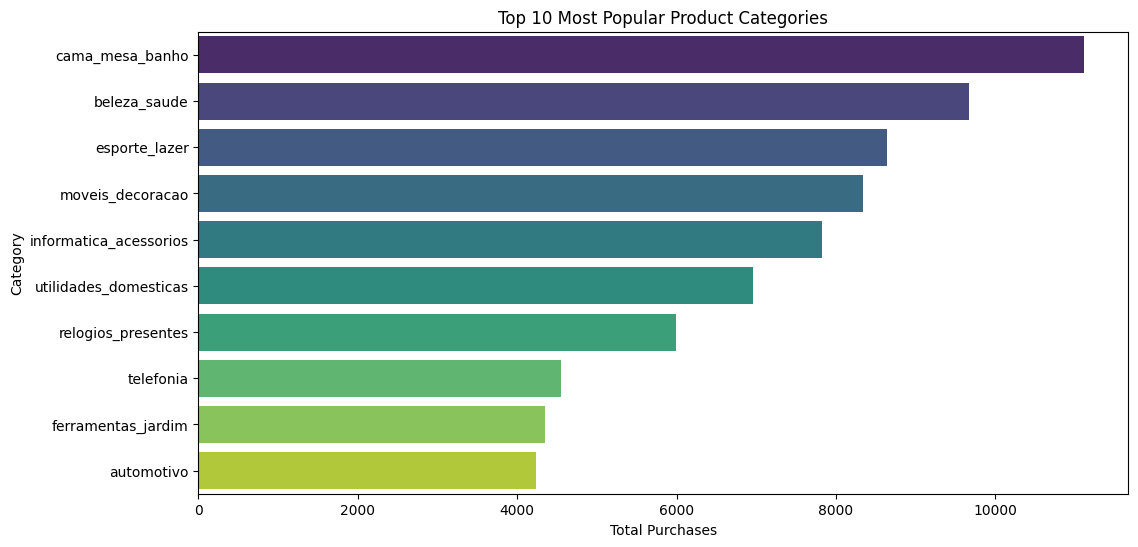

In [5]:
# Visualize Top 10 Popular Categories
top_categories = popular_products.groupby('product_category_name')['purchase_count'].sum().reset_index()
top_categories = top_categories.sort_values(by='purchase_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_categories, x='purchase_count', y='product_category_name', palette='viridis')
plt.title('Top 10 Most Popular Product Categories')
plt.xlabel('Total Purchases')
plt.ylabel('Category')
plt.show()

## 3. Collaborative Filtering (SVD)
We will use **Matrix Factorization** via **Truncated SVD** (Singular Value Decomposition) to find latent features that connect users and products.

**Challenge:** The matrix is huge (~95k users x ~32k products) and very sparse (most users bought only 1 item).

**Solution:**
1.  **Filter Data:** Keep only products that have been purchased at least X times (e.g., 5 or 10) to reduce noise and dimensionality.
2.  **Sparse Matrix:** Use `scipy.sparse` to handle the data efficiently.

In [6]:
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix

# 1. Filter Data: Keep products with at least 5 purchases
min_product_purchases = 5
product_counts = df.groupby('product_id')['purchase_count'].sum()
active_products = product_counts[product_counts >= min_product_purchases].index

df_filtered = df[df['product_id'].isin(active_products)]

print(f"Original Interactions: {len(df):,}")
print(f"Filtered Interactions: {len(df_filtered):,}")
print(f"Remaining Products: {df_filtered['product_id'].nunique():,}")

# 2. Create Pivot Table (User x Product)
# Since pivot_table can be memory intensive, we'll map IDs to indices and build a sparse matrix directly

# Map IDs to integer indices
user_ids = df_filtered['customer_unique_id'].unique()
product_ids = df_filtered['product_id'].unique()

user_to_idx = {user: i for i, user in enumerate(user_ids)}
product_to_idx = {product: i for i, product in enumerate(product_ids)}

# Reverse mapping for lookup later
idx_to_user = {i: user for user, i in user_to_idx.items()}
idx_to_product = {i: product for product, i in product_to_idx.items()}

# Create coordinate lists for sparse matrix
rows = df_filtered['customer_unique_id'].map(user_to_idx)
cols = df_filtered['product_id'].map(product_to_idx)
values = df_filtered['purchase_count']

# Create CSR Matrix
interaction_matrix = csr_matrix((values, (rows, cols)), shape=(len(user_ids), len(product_ids)))

print(f"Matrix Shape: {interaction_matrix.shape}")

Original Interactions: 101,987
Filtered Interactions: 60,927
Remaining Products: 4,832
Matrix Shape: (58678, 4832)


In [7]:
# 3. Train SVD Model
# We use TruncatedSVD which is designed for sparse matrices
n_components = 20  # Number of latent features. Low number prevents overfitting on sparse data.

svd = TruncatedSVD(n_components=n_components, random_state=42)
matrix_reduced = svd.fit_transform(interaction_matrix)

print(f"Explained Variance Ratio: {svd.explained_variance_ratio_.sum():.4f}")

# Calculate correlation matrix between products in the latent space
# Note: We are calculating item-item similarity based on latent features
corr_matrix = np.corrcoef(svd.components_.T)

print(f"Correlation Matrix Shape: {corr_matrix.shape}")

Explained Variance Ratio: 0.0997
Correlation Matrix Shape: (4832, 4832)


In [15]:
def recommend_products(product_id, n_recommendations=5):
    """
    Recommends similar products based on the correlation matrix.
    """
    if product_id not in product_to_idx:
        return []
    
    product_idx = product_to_idx[product_id]
    correlation_product_id = corr_matrix[product_idx]
    
    # Get indices of highly correlated products
    recommend_indices = correlation_product_id.argsort()[-n_recommendations-1:-1][::-1]
    
    
    recommended_products = []
    for idx in recommend_indices:
        rec_prod_id = idx_to_product[idx]
        recommended_products.append(rec_prod_id)
        
    return recommended_products

# Test Recommendation
# Let's pick a popular product and see what it recommends
test_product_id = popular_products.iloc[0]['product_id'] # Most popular product
test_product_name = popular_products.iloc[0]['product_category_name']

print(f"Recommendations for Product: {test_product_id} ({test_product_name})")
recommendations = recommend_products(test_product_id)

# Display details of recommended products
rec_details = products_df[products_df['product_id'].isin(recommendations)]
display(rec_details[['product_id', 'product_category_name']])

Recommendations for Product: aca2eb7d00ea1a7b8ebd4e68314663af (moveis_decoracao)


,product_id,product_category_name
1009,c857b96593773e940454e76efa8eabb3,moveis_decoracao
8870,f4f4debbcfcafe6858d1e37a1f6e436e,moveis_escritorio
17745,87283a98b24f9f1ac3a31b631073cf47,fashion_bolsas_e_acessorios
21859,28b4eced95a52d9c437a4caf9d311b95,moveis_decoracao
24162,7fb7c9580222a2af9eb7a95a6ce85fc5,utilidades_domesticas
